In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from config import DB_HOST, DB_PORT, DB_NAME, DB_USER, DB_PASS
from banco import conectar

# Configurações visuais dos gráficos
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10

# Engine SQLAlchemy para leitura de consultas SQL com Pandas
url_conexao = f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(url_conexao)
print("-> Ambiente configurado e pronto para consultas na Camada Gold.")

-> Ambiente configurado e pronto para consultas na Camada Gold.


In [5]:
conexao = conectar()
cursor = conexao.cursor()

# 1. Agregação de Pagamentos por Órgão e Tipo de Pagamento
CONSULTA_PAGAMENTO = """
SELECT 
    p.nome_orgao_pagador,
    p.tipo_pagamento,
    COUNT(*) AS qtd_pagamentos,
    SUM(p.valor) AS total_pago,
    AVG(p.valor) AS media_pago
FROM silver_pagamento p
JOIN silver_viagem v ON v.id_viagem = p.id_viagem
WHERE v.situacao = 'Realizada'
GROUP BY p.nome_orgao_pagador, p.tipo_pagamento
"""

cursor.execute("DROP TABLE IF EXISTS gold_pagamento_resumo CASCADE")
cursor.execute(f"CREATE TABLE gold_pagamento_resumo AS {CONSULTA_PAGAMENTO}")
cursor.execute(f"CREATE OR REPLACE VIEW vw_gold_pagamento_resumo AS {CONSULTA_PAGAMENTO}")

# 2. Agregação de Trechos por Meio de Transporte e Destino
CONSULTA_TRECHO = """
SELECT 
    t.meio_transporte,
    t.destino_uf,
    COUNT(*) AS total_trechos,
    SUM(t.numero_diarias) AS total_diarias
FROM silver_trecho t
JOIN silver_viagem v ON v.id_viagem = t.id_viagem
WHERE v.situacao = 'Realizada'
GROUP BY t.meio_transporte, t.destino_uf
"""

cursor.execute("DROP TABLE IF EXISTS gold_trecho_resumo CASCADE")
cursor.execute(f"CREATE TABLE gold_trecho_resumo AS {CONSULTA_TRECHO}")
cursor.execute(f"CREATE OR REPLACE VIEW vw_gold_trecho_resumo AS {CONSULTA_TRECHO}")

conexao.commit()
cursor.close()
conexao.close()
print("-> Camada Gold criada com sucesso: tabelas físicas e views agregadas.")

-> Camada Gold criada com sucesso: tabelas físicas e views agregadas.


,nome_orgao_superior,custo_total_milhoes
0,Ministério da Justiça e Segurança Pública,485.748241
1,Ministério da Defesa,154.595910
2,Ministério da Educação,109.759836
3,Ministério do Meio Ambiente e Mudança do Clima,49.300595
4,Ministério da Previdência Social,40.236181


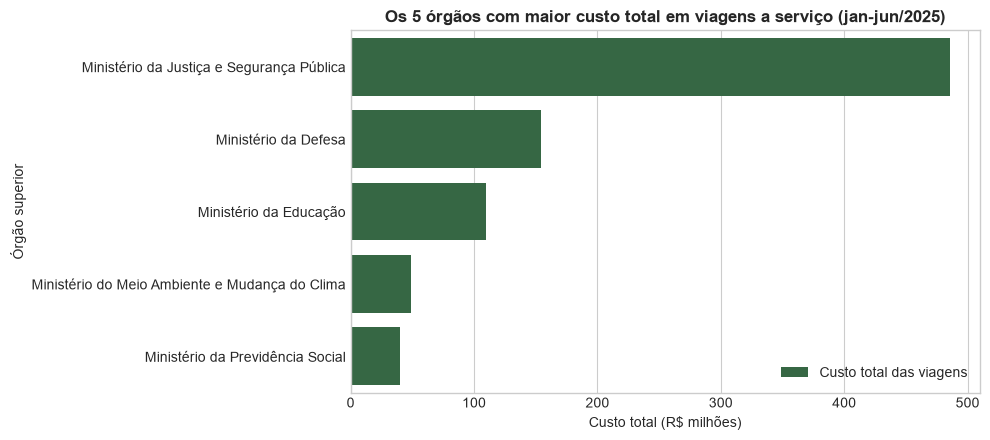

Conclusão: O Ministério da Justiça e Segurança Pública lidera com R$ 485.7 milhões em despesas.


In [6]:
query_p1 = """
SELECT 
    nome_orgao_superior,
    SUM(valor_total) / 1000000.0 AS custo_total_milhoes
FROM silver_viagem
WHERE situacao = 'Realizada'
GROUP BY nome_orgao_superior
ORDER BY custo_total_milhoes DESC
LIMIT 5;
"""
df_p1 = pd.read_sql(query_p1, engine)
display(df_p1)

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=df_p1, x="custo_total_milhoes", y="nome_orgao_superior", color="#2e6f40", ax=ax, label="Custo total das viagens")
ax.set_title("Os 5 órgãos com maior custo total em viagens a serviço (jan-jun/2025)", fontsize=12, fontweight="bold")
ax.set_xlabel("Custo total (R$ milhões)")
ax.set_ylabel("Órgão superior")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Conclusão: O {df_p1.iloc[0]['nome_orgao_superior']} lidera com R$ {df_p1.iloc[0]['custo_total_milhoes']:.1f} milhões em despesas.")

,destinos,total_viagens,custo_medio
0,"Brasília/DF, Brasília/DF",283,27401.797562
1,Genebra/Suíça,242,25469.222314
2,Nova York/Estados Unidos da América,149,21214.192215


C:\Users\Usuário\AppData\Local\Temp\ipykernel_16376\1442974641.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_p2, x="custo_medio", y="destinos", palette="Blues_r", ax=ax, label="Custo médio")


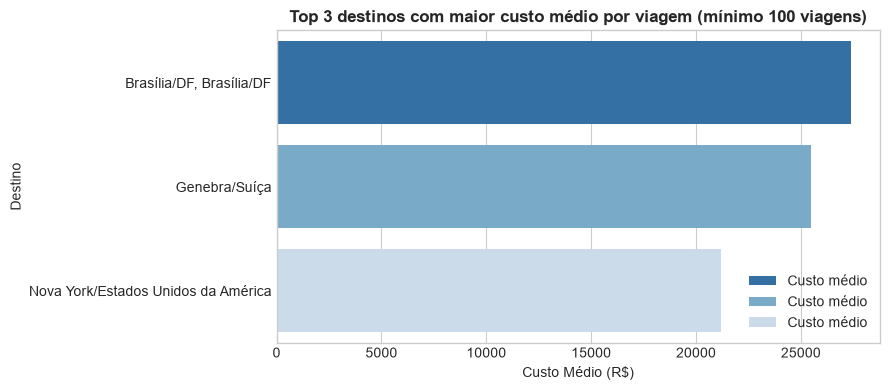

Conclusão: O destino 'Brasília/DF, Brasília/DF' obteve o maior custo médio: R$ 27,401.80.


In [7]:
query_p2 = """
SELECT 
    destinos,
    COUNT(*) AS total_viagens,
    AVG(valor_total) AS custo_medio
FROM silver_viagem
WHERE situacao = 'Realizada'
GROUP BY destinos
HAVING COUNT(*) >= 100
ORDER BY custo_medio DESC
LIMIT 3;
"""
df_p2 = pd.read_sql(query_p2, engine)
display(df_p2)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=df_p2, x="custo_medio", y="destinos", palette="Blues_r", ax=ax, label="Custo médio")
ax.set_title("Top 3 destinos com maior custo médio por viagem (mínimo 100 viagens)", fontsize=12, fontweight="bold")
ax.set_xlabel("Custo Médio (R$)")
ax.set_ylabel("Destino")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Conclusão: O destino '{df_p2.iloc[0]['destinos']}' obteve o maior custo médio: R$ {df_p2.iloc[0]['custo_medio']:,.2f}.")

In [8]:
query_p3 = """
SELECT 
    id_viagem,
    nome_orgao_superior,
    data_inicio,
    data_fim,
    duracao_dias,
    valor_total
FROM silver_viagem
WHERE situacao = 'Realizada'
ORDER BY duracao_dias DESC
LIMIT 1;
"""
df_p3 = pd.read_sql(query_p3, engine)
display(df_p3)

row = df_p3.iloc[0]
print(f"Conclusão: A viagem mais longa durou {int(row['duracao_dias'])} dias (de {row['data_inicio']} a {row['data_fim']}), "
      f"pertencente ao {row['nome_orgao_superior']}, com custo registrado de R$ {row['valor_total']:.2f}.")

,id_viagem,nome_orgao_superior,data_inicio,data_fim,duracao_dias,valor_total
0,0000000000020699856,Ministério da Previdência Social,2025-01-13,2026-01-31,384,0.0


Conclusão: A viagem mais longa durou 384 dias (de 2025-01-13 a 2026-01-31), pertencente ao Ministério da Previdência Social, com custo registrado de R$ 0.00.


,tipo_pagamento,quantidade,valor_medio
0,DIÁRIAS,400364,2078.787645
1,PASSAGEM,182883,1882.317620
2,Serviço correlato: seguro,4789,447.256897
3,RESTITUIÇÃO,11574,245.702610


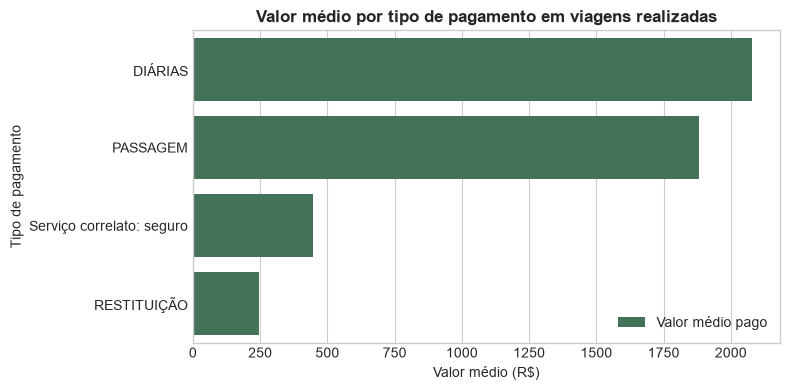

Conclusão: O tipo de pagamento 'DIÁRIAS' obteve a maior média: R$ 2,078.79.


In [9]:
query_p4 = """
SELECT 
    tipo_pagamento,
    COUNT(*) AS quantidade,
    AVG(valor) AS valor_medio
FROM silver_pagamento p
JOIN silver_viagem v ON v.id_viagem = p.id_viagem
WHERE v.situacao = 'Realizada'
GROUP BY tipo_pagamento
ORDER BY valor_medio DESC;
"""
df_p4 = pd.read_sql(query_p4, engine)
display(df_p4)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df_p4, x="valor_medio", y="tipo_pagamento", color="#3b7a57", ax=ax, label="Valor médio pago")
ax.set_title("Valor médio por tipo de pagamento em viagens realizadas", fontsize=12, fontweight="bold")
ax.set_xlabel("Valor médio (R$)")
ax.set_ylabel("Tipo de pagamento")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Conclusão: O tipo de pagamento '{df_p4.iloc[0]['tipo_pagamento']}' obteve a maior média: R$ {df_p4.iloc[0]['valor_medio']:,.2f}.")

,meio_transporte,total_trechos
0,Veículo Oficial,385734
1,Aéreo,226707
2,Rodoviário,64454
3,Veículo Próprio,42736
4,Inválido,26523
5,Fluvial,8392
6,Ferroviário,868
7,Marítimo,471


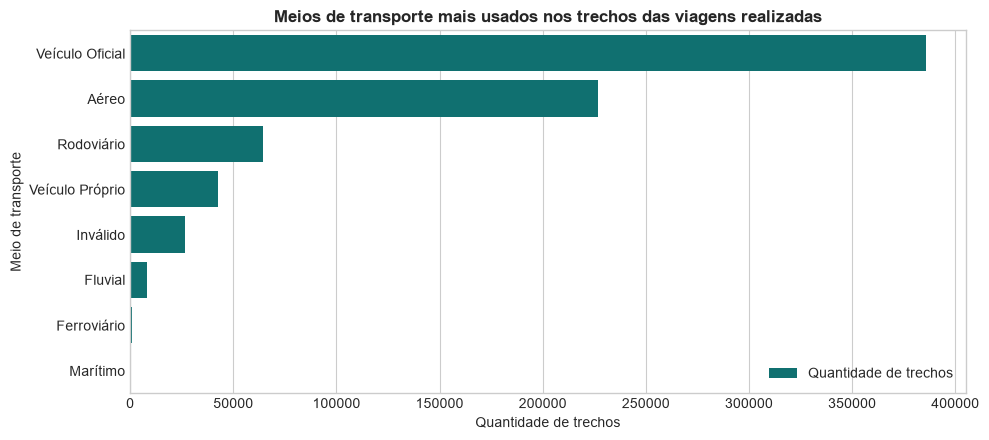

Conclusão: O transporte mais frequente foi 'Veículo Oficial' com 385,734 trechos (51.0% do total).


In [10]:
query_p5 = """
SELECT 
    meio_transporte,
    COUNT(*) AS total_trechos
FROM silver_trecho t
JOIN silver_viagem v ON v.id_viagem = t.id_viagem
WHERE v.situacao = 'Realizada'
GROUP BY meio_transporte
ORDER BY total_trechos DESC;
"""
df_p5 = pd.read_sql(query_p5, engine)
display(df_p5)

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=df_p5, x="total_trechos", y="meio_transporte", color="#008080", ax=ax, label="Quantidade de trechos")
ax.set_title("Meios de transporte mais usados nos trechos das viagens realizadas", fontsize=12, fontweight="bold")
ax.set_xlabel("Quantidade de trechos")
ax.set_ylabel("Meio de transporte")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

pct = (df_p5.iloc[0]['total_trechos'] / df_p5['total_trechos'].sum()) * 100
print(f"Conclusão: O transporte mais frequente foi '{df_p5.iloc[0]['meio_transporte']}' com {df_p5.iloc[0]['total_trechos']:,} trechos ({pct:.1f}% do total).")

,destino_uf,total_trechos
0,São Paulo,81727
1,Distrito Federal,77962
2,Minas Gerais,50555
3,Rio de Janeiro,43481
4,Paraná,42323
5,Pará,39742
6,Rio Grande do Sul,38397
7,Mato Grosso do Sul,30450
8,Bahia,28141
9,Pernambuco,28117


C:\Users\Usuário\AppData\Local\Temp\ipykernel_16376\4113324653.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_p6, x="total_trechos", y="destino_uf", palette="viridis", ax=ax, label="Trechos recebidos")


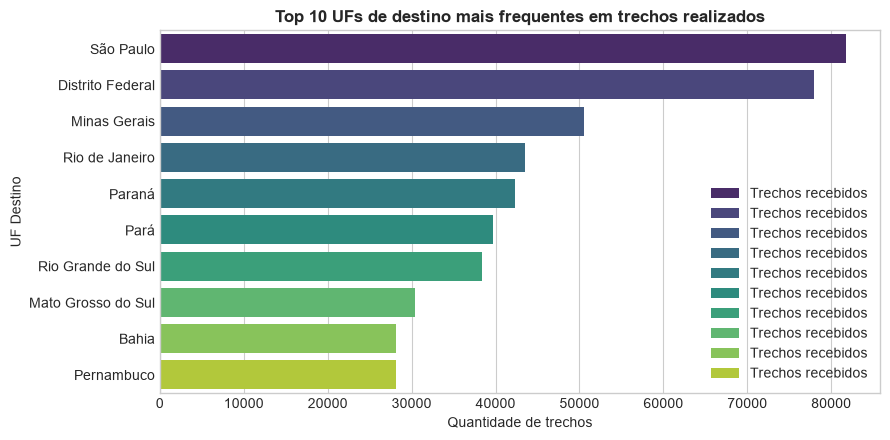

Conclusão: A UF de destino mais presente foi 'São Paulo' com 81,727 trechos.


In [11]:
query_p6 = """
SELECT 
    destino_uf,
    COUNT(*) AS total_trechos
FROM silver_trecho t
JOIN silver_viagem v ON v.id_viagem = t.id_viagem
WHERE v.situacao = 'Realizada' AND destino_uf IS NOT NULL AND destino_uf != ''
GROUP BY destino_uf
ORDER BY total_trechos DESC
LIMIT 10;
"""
df_p6 = pd.read_sql(query_p6, engine)
display(df_p6)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=df_p6, x="total_trechos", y="destino_uf", palette="viridis", ax=ax, label="Trechos recebidos")
ax.set_title("Top 10 UFs de destino mais frequentes em trechos realizados", fontsize=12, fontweight="bold")
ax.set_xlabel("Quantidade de trechos")
ax.set_ylabel("UF Destino")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Conclusão: A UF de destino mais presente foi '{df_p6.iloc[0]['destino_uf']}' com {df_p6.iloc[0]['total_trechos']:,} trechos.")

,nome_orgao_pagador,total_pago_milhoes
0,Fundo Nacional de Segurança Pública,278.288685
1,Sigiloso,199.308482
2,Comando da Aeronáutica,81.069603
3,Instituto Nacional do Seguro Social,37.254698
4,Comando do Exército,36.576136


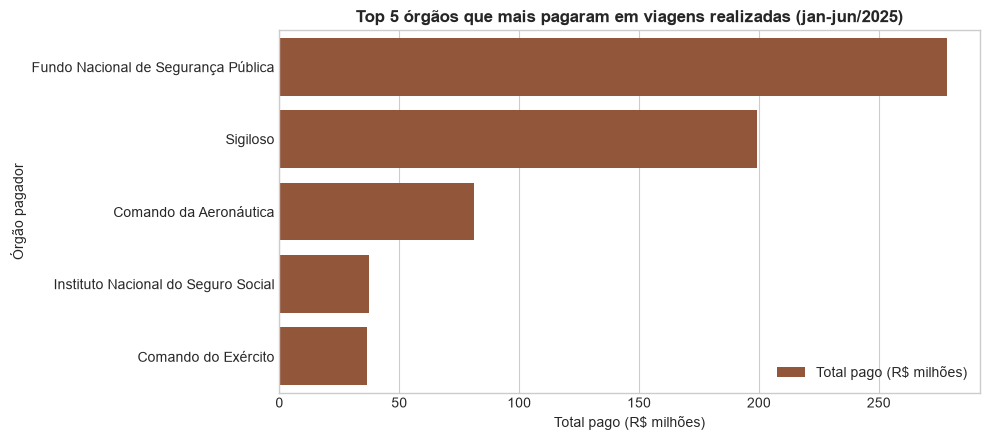

Conclusão: O órgão que realizou o maior montante de pagamentos foi 'Fundo Nacional de Segurança Pública', somando R$ 278.3 milhões.


In [12]:
query_p7 = """
SELECT 
    nome_orgao_pagador,
    SUM(valor) / 1000000.0 AS total_pago_milhoes
FROM silver_pagamento p
JOIN silver_viagem v ON v.id_viagem = p.id_viagem
WHERE v.situacao = 'Realizada'
GROUP BY nome_orgao_pagador
ORDER BY total_pago_milhoes DESC
LIMIT 5;
"""
df_p7 = pd.read_sql(query_p7, engine)
display(df_p7)

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=df_p7, x="total_pago_milhoes", y="nome_orgao_pagador", color="#a0522d", ax=ax, label="Total pago (R$ milhões)")
ax.set_title("Top 5 órgãos que mais pagaram em viagens realizadas (jan-jun/2025)", fontsize=12, fontweight="bold")
ax.set_xlabel("Total pago (R$ milhões)")
ax.set_ylabel("Órgão pagador")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Conclusão: O órgão que realizou o maior montante de pagamentos foi '{df_p7.iloc[0]['nome_orgao_pagador']}', somando R$ {df_p7.iloc[0]['total_pago_milhoes']:.1f} milhões.")